In [1]:
import sys, time, os, json, sqlite3, gc, shutil
import pandas as pd, numpy as np, psutil
from google.colab import drive
from sqlalchemy import create_engine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# ==========================================
# K-1. PERSIAPAN LINGKUNGAN DAN LOGGING
# ==========================================
print("--- K-1. Persiapan Lingkungan ---")
for nama in ["pandas", "numpy", "pyarrow", "requests", "sklearn", "sqlalchemy"]:
    try:
        mod = __import__(nama)
        print(f"{nama:11s} : {mod.__version__}")
    except ImportError:
        print(f"{nama:11s} : BELUM TERPASANG")

# Mount Google Drive
drive.mount("/content/drive")

# Definisi Direktori
DIR_MENTAH = "/content/lapisan_mentah"
DIR_KURASI = "/content/lapisan_terkurasi"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum2"

for d in (DIR_MENTAH, DIR_KURASI, DIR_SIMPAN):
    os.makedirs(d, exist_ok=True)

# Profiling Memori & Waktu Eksekusi
proses = psutil.Process(os.getpid())
catatan = []

def rss_mb():
    return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
    m0, t0 = rss_mb(), time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - t0
    catatan.append({"langkah": label, "detik": round(detik, 2), "delta_rss_mb": round(rss_mb() - m0, 1)})
    print(f"[{label}] {detik:.2f} s")
    return hasil

# Lineage Data
lineage = []

def catat_sumber(nama, asal, jumlah_baris, keterangan=""):
    lineage.append({
        "sumber": nama, "asal": asal,
        "diambil_pada": pd.Timestamp.now("UTC").isoformat(),
        "jumlah_baris": jumlah_baris, "keterangan": keterangan,
    })
    print(f"[lineage] {nama}: {jumlah_baris:,} baris")

import requests

--- K-1. Persiapan Lingkungan ---
pandas      : 2.2.3
numpy       : 2.1.3
pyarrow     : 23.0.1
requests    : 2.32.4
sklearn     : 1.6.1
sqlalchemy  : 2.0.54
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import requests, shutil, os, time

def unduh_aman(url, tujuan, percobaan=3, jeda_awal=2):
    """Unduh dengan retry + penulisan atomik. Melewati unduhan bila file sudah ada."""
    if os.path.exists(tujuan) and os.path.getsize(tujuan) > 0:
        print("cache ditemukan:", os.path.basename(tujuan))
        return tujuan

    sementara = tujuan + ".part"

    # Menambahkan identitas browser agar tidak diblokir server
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}

    for i in range(percobaan):
        try:
            with requests.get(url, stream=True, timeout=60, headers=headers) as r:
                r.raise_for_status()
                with open(sementara, "wb") as f:
                    shutil.copyfileobj(r.raw, f)

            # Validasi jika file sangat kecil (misal kurang dari 1KB) kemungkinan error/kosong
            if os.path.getsize(sementara) < 1000:
                raise IOError(f"berkas terlalu kecil atau kosong (ukuran: {os.path.getsize(sementara)} bytes)")

            os.replace(sementara, tujuan) # atomik
            return tujuan
        except Exception as e:
            jeda = jeda_awal * (2 ** i) # exponential backoff
            print(f"percobaan {i+1} gagal ({e}); menunggu {jeda}s")
            time.sleep(jeda)

    raise RuntimeError(f"gagal mengunduh setelah {percobaan} percobaan: {url}")

URL_TRIP = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet"
URL_ZONA = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"

PATH_TRIP = os.path.join(DIR_MENTAH, "yellow_tripdata_2023-01.parquet")
PATH_ZONA = os.path.join(DIR_MENTAH, "taxi_zone_lookup.csv")

ukur("unduh trip", lambda: unduh_aman(URL_TRIP, PATH_TRIP))
ukur("unduh zona", lambda: unduh_aman(URL_ZONA, PATH_ZONA))

for pth in (PATH_TRIP, PATH_ZONA):
    print(os.path.basename(pth), "->", round(os.path.getsize(pth)/1024**2, 2), "MB")

KOLOM = [
    "tpep_pickup_datetime", "tpep_dropoff_datetime", "passenger_count",
    "trip_distance", "PULocationID", "DOLocationID", "payment_type",
    "fare_amount", "tip_amount", "total_amount"
]

trip = ukur("baca trip", lambda: pd.read_parquet(PATH_TRIP, columns=KOLOM))
zona = pd.read_csv(URL_ZONA)

catat_sumber("trip", URL_TRIP, len(trip), "Parquet bulanan TLC")
catat_sumber("zona", URL_ZONA, len(zona), "tabel dimensi 265 zona")

display(zona.head())

cache ditemukan: yellow_tripdata_2023-01.parquet
[unduh trip] 0.00 s
cache ditemukan: taxi_zone_lookup.csv
[unduh zona] 0.00 s
yellow_tripdata_2023-01.parquet -> 45.46 MB
taxi_zone_lookup.csv -> 0.0 MB
[baca trip] 1.16 s
[lineage] trip: 3,066,766 baris
[lineage] zona: 265 baris


,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


In [3]:
API_CUACA = "https://archive-api.open-meteo.com/v1/archive"

def ambil_cuaca(mulai, selesai, lat=40.7128, lon=-74.0060, percobaan=3):
    parameter = {
        "latitude": lat, "longitude": lon,
        "start_date": mulai, "end_date": selesai,
        "hourly": "temperature_2m,precipitation",
        "timezone": "America/New_York",
    }
    for i in range(percobaan):
        r = requests.get(API_CUACA, params=parameter, timeout=60)
        if r.status_code == 200:
            data = r.json()
            if "hourly" not in data:  # validasi struktur
                raise ValueError("kunci 'hourly' tidak ada pada respons")
            return pd.DataFrame(data["hourly"])
        if r.status_code in (429, 500, 502, 503):  # layak dicoba ulang
            time.sleep(2 ** i)
            continue
        r.raise_for_status()  # galat lain: hentikan
    raise RuntimeError("API cuaca tidak merespons dengan benar")

cuaca = ukur("ambil cuaca", lambda: ambil_cuaca("2023-01-01", "2023-01-31"))
cuaca["time"] = pd.to_datetime(cuaca["time"])
cuaca = cuaca.rename(columns={"time": "jam_mulai",
                               "temperature_2m": "suhu_c",
                               "precipitation": "hujan_mm"})
catat_sumber("cuaca", API_CUACA, len(cuaca), "Open-Meteo hourly archive")
cuaca.head()

[ambil cuaca] 0.50 s
[lineage] cuaca: 744 baris


,jam_mulai,suhu_c,hujan_mm
0,2023-01-01 00:00:00,10.9,1.0
1,2023-01-01 01:00:00,10.6,1.0
2,2023-01-01 02:00:00,10.6,0.1
3,2023-01-01 03:00:00,10.5,0.0
4,2023-01-01 04:00:00,9.8,0.0


In [4]:
from sqlalchemy import create_engine

PATH_DB = os.path.join(DIR_MENTAH, "operasional.db")
engine = create_engine(f"sqlite:///{PATH_DB}")

tarif_referensi = pd.DataFrame({
    "payment_type": [1, 2, 3, 4, 5, 6],
    "nama_pembayaran": ["Kartu kredit", "Tunai", "Gratis",
                         "Sengketa", "Tidak diketahui", "Perjalanan batal"],
    "kena_biaya_admin": [1, 0, 0, 0, 0, 0],
})
tarif_referensi.to_sql("tarif_referensi", engine, if_exists="replace", index=False)

# tabel transaksi tiruan untuk latihan pembacaan bertahap
trip.head(300_000).to_sql(
    "trip_operasional", engine, if_exists="replace",
    index=False, chunksize=50_000)

print("Tabel dibuat:", pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table'", engine)["name"].tolist())

SQL = """
    SELECT payment_type, COUNT(*) AS jumlah, AVG(total_amount) AS rata_total
    FROM trip_operasional
    WHERE total_amount > 0
    GROUP BY payment_type
    ORDER BY jumlah DESC
"""
ringkas_db = pd.read_sql(SQL, engine)
print(ringkas_db)

# Pembacaan bertahap: agregasi tanpa memuat seluruh tabel ke memori
total_baris = 0
for bagian in pd.read_sql("SELECT trip_distance FROM trip_operasional",
                           engine, chunksize=50_000):
    total_baris += len(bagian)
print("dibaca bertahap:", f"{total_baris:,}", "baris")

tarif_referensi = pd.read_sql("SELECT * FROM tarif_referensi", engine)
catat_sumber("tarif_referensi", PATH_DB, len(tarif_referensi),
             "tabel dimensi dari basis data operasional")

Tabel dibuat: ['tarif_referensi', 'trip_operasional']
   payment_type  jumlah  rata_total
0             1  226967   31.339172
1             2   66504   25.218836
2             4    2082   26.611114
3             3    1553   22.089691
dibaca bertahap: 300,000 baris
[lineage] tarif_referensi: 6 baris


In [5]:
trip["durasi_menit"] = (
    (trip["tpep_dropoff_datetime"] - trip["tpep_pickup_datetime"])
    .dt.total_seconds() / 60)

def profil_kolom(df):
    baris = []
    for kol in df.columns:
        s = df[kol]
        baris.append({
            "kolom": kol, "tipe": str(s.dtype),
            "persen_hilang": round(100 * s.isna().mean(), 3),
            "nilai_unik": s.nunique(dropna=True),
            "contoh": s.dropna().iloc[0] if s.notna().any() else None,
        })
    return pd.DataFrame(baris)

profil = profil_kolom(trip)
profil

AWAL, AKHIR = pd.Timestamp("2023-01-01"), pd.Timestamp("2023-02-01")
zona_sah = set(zona["LocationID"])

aturan = {
    "kelengkapan: passenger_count ada": trip["passenger_count"].notna(),
    "keunikan: baris tidak duplikat": ~trip.duplicated(),
    "validitas: jarak 0-100 mil": trip["trip_distance"].between(0.01, 100),
    "validitas: total_amount > 0": trip["total_amount"] > 0,
    "validitas: PULocationID dikenal": trip["PULocationID"].isin(zona_sah),
    "konsistensi: durasi 1-180 menit": trip["durasi_menit"].between(1, 180),
    "konsistensi: total >= fare": trip["total_amount"] >= trip["fare_amount"],
    "ketepatan waktu: dalam Jan 2023": trip["tpep_pickup_datetime"].between(AWAL, AKHIR),
}

laporan = pd.DataFrame([
    {"aturan": nama, "lulus": int(mask.sum()), "gagal": int((~mask).sum()),
     "persen_gagal": round(100 * (~mask).mean(), 3)}
    for nama, mask in aturan.items()
]).sort_values("persen_gagal", ascending=False)
laporan

,aturan,lulus,gagal,persen_gagal
0,kelengkapan: passenger_count ada,2995023,71743,2.339
2,validitas: jarak 0-100 mil,3020816,45950,1.498
5,konsistensi: durasi 1-180 menit,3030383,36383,1.186
3,validitas: total_amount > 0,3040994,25772,0.840
6,konsistensi: total >= fare,3041743,25023,0.816
7,ketepatan waktu: dalam Jan 2023,3066718,48,0.002
1,keunikan: baris tidak duplikat,3066766,0,0.000
4,validitas: PULocationID dikenal,3066766,0,0.000


In [6]:
KOL = "passenger_count"
asli = trip[KOL]
print("persen hilang:", round(100 * asli.isna().mean(), 3))

trip["jam"] = trip["tpep_pickup_datetime"].dt.hour

strategi = {
    "1_dibuang": asli.dropna(),
    "2_isi_median": asli.fillna(asli.median()),
    "3_isi_modus": asli.fillna(asli.mode().iloc[0]),
    "4_median_perjam": asli.fillna(trip.groupby("jam")[KOL].transform("median")),
}

banding = pd.DataFrame([
    {"strategi": nama, "n": len(s), "mean": round(s.mean(), 4),
     "median": s.median(), "std": round(s.std(), 4)}
    for nama, s in strategi.items()
])
banding

# Strategi yang dipilih modul ini: tandai + isi per kelompok (lihat G.4)
trip[KOL + "_hilang"] = trip[KOL].isna().astype("int8")
trip[KOL] = trip[KOL].fillna(trip.groupby("jam")[KOL].transform("median"))
trip[KOL] = trip[KOL].fillna(trip[KOL].median())  # jaring pengaman

# Duplikat: periksa dua tingkat
dup_penuh = trip.duplicated().sum()
KUNCI = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "PULocationID", "DOLocationID", "total_amount"]
dup_kunci = trip.duplicated(subset=KUNCI).sum()
print(f"duplikat penuh: {dup_penuh:,} | duplikat pada kunci: {dup_kunci:,}")

sebelum = len(trip)
trip = trip.drop_duplicates(subset=KUNCI, keep="first").reset_index(drop=True)
print(f"{sebelum:,} -> {len(trip):,} baris")

persen hilang: 2.339
duplikat penuh: 0 | duplikat pada kunci: 1
3,066,766 -> 3,066,765 baris


In [7]:
def batas_iqr(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

def ringkas_outlier(df, kolom):
    hasil = []
    for kol in kolom:
        s = df[kol].dropna()
        lo, hi = batas_iqr(s)
        z = (s - s.mean()) / s.std()
        hasil.append({
            "kolom": kol, "batas_bawah": round(lo, 2), "batas_atas": round(hi, 2),
            "outlier_iqr": int(((s < lo) | (s > hi)).sum()),
            "outlier_z3": int((z.abs() > 3).sum()), "p99": round(s.quantile(0.99), 2),
        })
    return pd.DataFrame(hasil)

ringkas_outlier(trip, ["trip_distance", "durasi_menit", "total_amount"])

# Tindakan berbeda untuk maksud berbeda (lihat G.5)
layak = (trip["trip_distance"].between(0.01, 100)
         & trip["durasi_menit"].between(1, 180)
         & (trip["total_amount"] > 0))
bersih = trip.loc[layak].copy()

# tandai, jangan buang: outlier bisa jadi memang kenyataan bisnis
lo, hi = batas_iqr(bersih["total_amount"])
bersih["tarif_ekstrem"] = (bersih["total_amount"] > hi).astype("int8")

# winsorizing hanya untuk kolom turunan yang akan dipakai model
batas_atas = bersih["trip_distance"].quantile(0.995)
bersih["trip_distance_capped"] = bersih["trip_distance"].clip(upper=batas_atas)

print(f"{len(trip):,} -> {len(bersih):,} baris "
      f"({100*(1-len(bersih)/len(trip)):.2f}% dibuang)")

# --- Join 1: tabel zona (dimensi) ---
print("kunci zona unik?", zona["LocationID"].is_unique)  # WAJIB diperiksa

n0 = len(bersih)
bersih = bersih.merge(
    zona[["LocationID", "Borough", "Zone"]]
        .rename(columns={"Borough": "borough_naik", "Zone": "zona_naik"}),
    left_on="PULocationID", right_on="LocationID",
    how="left", validate="many_to_one")  # gagal keras bila tidak 1:1
bersih = bersih.drop(columns="LocationID")
print(f"baris {n0:,} -> {len(bersih):,} (harus sama)")
print("zona tak dikenal:", bersih["zona_naik"].isna().sum())

# --- Join 2: tabel pembayaran dari basis data ---
bersih = bersih.merge(tarif_referensi[["payment_type", "nama_pembayaran"]],
                       on="payment_type", how="left", validate="many_to_one")

# --- Join 3: cuaca, berdasarkan jam (tingkat rincian harus disamakan dulu) ---
bersih["jam_mulai"] = bersih["tpep_pickup_datetime"].dt.floor("h")
n0 = len(bersih)
bersih = bersih.merge(cuaca, on="jam_mulai", how="left", validate="many_to_one")
print(f"baris {n0:,} -> {len(bersih):,}")
print("tanpa data cuaca:", bersih["suhu_c"].isna().sum())

3,066,765 -> 2,986,910 baris (2.60% dibuang)
kunci zona unik? True
baris 2,986,910 -> 2,986,910 (harus sama)
zona tak dikenal: 37609
baris 2,986,910 -> 2,986,910
tanpa data cuaca: 37


In [8]:
bersih["hari_minggu"] = bersih["tpep_pickup_datetime"].dt.dayofweek
bersih["akhir_pekan"] = (bersih["hari_minggu"] >= 5).astype("int8")
bersih["kecepatan_mph"] = (bersih["trip_distance"] / (bersih["durasi_menit"] / 60)).round(2)
bersih["tarif_per_mil"] = (bersih["total_amount"] / bersih["trip_distance"]).round(3)
bersih["hujan"] = (bersih["hujan_mm"].fillna(0) > 0.1).astype("int8")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

FITUR_NUM = ["trip_distance_capped", "durasi_menit", "suhu_c"]
FITUR_KAT = ["nama_pembayaran", "borough_naik"]

contoh = bersih.dropna(subset=FITUR_NUM + FITUR_KAT).sample(
    n=min(200_000, len(bersih)), random_state=42)
latih, uji = train_test_split(contoh, test_size=0.2, random_state=42)

skala = StandardScaler().fit(latih[FITUR_NUM])  # fit HANYA di data latih
latih_num = skala.transform(latih[FITUR_NUM])
uji_num = skala.transform(uji[FITUR_NUM])  # transform saja, tanpa fit ulang
print("mean latih (harus ~0):", latih_num.mean(axis=0).round(3))
print("mean uji (tidak harus 0):", uji_num.mean(axis=0).round(3))

# Bergantung versi: parameter sparse_output ada sejak scikit-learn 1.2
enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
enc.fit(latih[FITUR_KAT])
latih_kat = enc.transform(latih[FITUR_KAT])
print("jumlah kolom hasil one-hot:", latih_kat.shape[1])
print("nama kolom:", enc.get_feature_names_out()[:6], "...")

mean latih (harus ~0): [-0.  0. -0.]
mean uji (tidak harus 0): [ 0.001  0.001 -0.009]
jumlah kolom hasil one-hot: 11
nama kolom: ['nama_pembayaran_Gratis' 'nama_pembayaran_Kartu kredit'
 'nama_pembayaran_Sengketa' 'nama_pembayaran_Tunai' 'borough_naik_Bronx'
 'borough_naik_Brooklyn'] ...


In [9]:
KONTRAK = {
    "tpep_pickup_datetime": "datetime64[ns]", "trip_distance": "float64",
    "durasi_menit": "float64", "total_amount": "float64",
    "borough_naik": "object", "nama_pembayaran": "object",
}

def validasi(df, kontrak=KONTRAK):
    masalah = []
    for kol, tipe in kontrak.items():
        if kol not in df.columns:
            masalah.append(f"kolom hilang: {kol}")
        elif not str(df[kol].dtype).startswith(tipe.split("[")[0]):
            masalah.append(f"tipe {kol}: {df[kol].dtype} != {tipe}")
    if df.empty:
        masalah.append("DataFrame kosong")
    if len(df) != len(df.drop_duplicates(subset=KUNCI)):
        masalah.append("masih ada duplikat pada kunci")
    if masalah:
        raise AssertionError("Validasi gagal:\n- " + "\n- ".join(masalah))
    print(f"Validasi lulus: {len(df):,} baris x {df.shape[1]} kolom")
    return df

validasi(bersih)

def pipeline(path_trip, path_zona, df_cuaca, df_tarif):
    """Satu fungsi, idempoten: input mentah -> DataFrame tervalidasi."""
    df = pd.read_parquet(path_trip, columns=KOLOM)
    z = pd.read_csv(path_zona, compression='gzip')

    df["durasi_menit"] = ((df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"])
                           .dt.total_seconds() / 60)
    df["jam"] = df["tpep_pickup_datetime"].dt.hour
    df["passenger_count"] = df["passenger_count"].fillna(
        df.groupby("jam")["passenger_count"].transform("median"))

    df = df.drop_duplicates(subset=KUNCI)
    df = df[df["trip_distance"].between(0.01, 100)
            & df["durasi_menit"].between(1, 180)
            & (df["total_amount"] > 0)]

    df = (df.merge(z[["LocationID", "Borough"]]
                    .rename(columns={"Borough": "borough_naik"}),
                    left_on="PULocationID", right_on="LocationID",
                    how="left", validate="many_to_one")
            .drop(columns="LocationID")
            .merge(df_tarif[["payment_type", "nama_pembayaran"]],
                   on="payment_type", how="left", validate="many_to_one"))

    df["jam_mulai"] = df["tpep_pickup_datetime"].dt.floor("h")
    df = df.merge(df_cuaca, on="jam_mulai", how="left", validate="many_to_one")

    return validasi(df)

hasil = ukur("pipeline penuh", lambda: pipeline(PATH_TRIP, PATH_ZONA, cuaca, tarif_referensi))

OUT = os.path.join(DIR_KURASI, "trips_bersih")
hasil["tanggal"] = hasil["tpep_pickup_datetime"].dt.date.astype(str)
ukur("tulis parquet berpartisi", lambda: hasil.to_parquet(
    OUT, partition_cols=["borough_naik"], index=False))
print("partisi yang terbentuk:", sorted(os.listdir(OUT))[:5], "...")

# Bukti idempotensi: jalankan ulang, hasil harus identik
ulang = pipeline(PATH_TRIP, PATH_ZONA, cuaca, tarif_referensi)
print("idempoten?", len(ulang) == len(hasil))

# Artefak yang dikumpulkan
laporan.to_csv(f"{DIR_SIMPAN}/laporan_kualitas.csv", index=False)
pd.DataFrame(lineage).to_csv(f"{DIR_SIMPAN}/lineage.csv", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)
shutil.make_archive(f"{DIR_SIMPAN}/trips_bersih", "zip", OUT)

Validasi lulus: 2,986,910 baris x 26 kolom
Validasi lulus: 2,986,910 baris x 17 kolom
[pipeline penuh] 7.55 s
[tulis parquet berpartisi] 3.33 s
partisi yang terbentuk: ['borough_naik=Bronx', 'borough_naik=Brooklyn', 'borough_naik=EWR', 'borough_naik=Manhattan', 'borough_naik=Queens'] ...
Validasi lulus: 2,986,910 baris x 17 kolom
idempoten? True


'/content/drive/MyDrive/BigData/Praktikum2/trips_bersih.zip'

In [10]:
!pip install -q pyspark==3.5.1
from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder.appName("BD-P02").master("local[*]")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")

sdf = spark.read.parquet(PATH_TRIP).select(*KOLOM)
szona = spark.createDataFrame(zona[["LocationID", "Borough"]])

sbersih = (sdf
    .withColumn("durasi_menit",
        (F.unix_timestamp("tpep_dropoff_datetime")
         - F.unix_timestamp("tpep_pickup_datetime")) / 60)
    .filter(F.col("trip_distance").between(0.01, 100))
    .filter(F.col("durasi_menit").between(1, 180))
    .filter(F.col("total_amount") > 0)
    .dropDuplicates(["tpep_pickup_datetime", "tpep_dropoff_datetime",
                      "PULocationID", "DOLocationID", "total_amount"])
    .join(F.broadcast(szona),  # tabel kecil: broadcast
          sdf.PULocationID == szona.LocationID, "left")
    .drop("LocationID"))

ukur("spark: hitung baris bersih", lambda: sbersih.count())
sbersih.groupBy("Borough").count().orderBy(F.desc("count")).show(10, False)

sbersih.write.mode("overwrite").partitionBy("Borough") \
    .parquet("/content/lapisan_terkurasi/trips_spark")

sbersih.explain()  # cari BroadcastHashJoin, bukan SortMergeJoin
spark.stop()

[spark: hitung baris bersih] 16.14 s
+-------------+-------+
|Borough      |count  |
+-------------+-------+
|Manhattan    |2659609|
|Queens       |270315 |
|Unknown      |37609  |
|Brooklyn     |15724  |
|Bronx        |3074   |
|NaN          |340    |
|Staten Island|211    |
|EWR          |28     |
+-------------+-------+

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [tpep_pickup_datetime#1, tpep_dropoff_datetime#2, passenger_count#245, trip_distance#247, PULocationID#7L, DOLocationID#8L, payment_type#249L, fare_amount#251, tip_amount#253, total_amount#16, durasi_menit#255, Borough#50]
   +- BroadcastHashJoin [PULocationID#7L], [LocationID#49L], LeftOuter, BuildRight, false
      :- HashAggregate(keys=[DOLocationID#8L, tpep_dropoff_datetime#2, PULocationID#7L, total_amount#16, tpep_pickup_datetime#1], functions=[first(passenger_count#3, false), first(trip_distance#4, false), first(payment_type#9L, false), first(fare_amount#10, false), first(tip_amount#13, false),

In [11]:
import pandas as pd

KOL = "passenger_count"
asli = trip[KOL]
if "jam" not in trip.columns:
    trip["jam"] = trip["tpep_pickup_datetime"].dt.hour

strategi = {
    "1_dibuang": asli.dropna(),
    "2_isi_median": asli.fillna(asli.median()),
    "3_isi_modus": asli.fillna(asli.mode().iloc[0]),
    "4_median_perjam": asli.fillna(trip.groupby("jam")[KOL].transform("median")),
}

banding = pd.DataFrame([
    {"strategi": nama, "n": len(s), "mean": round(s.mean(), 4),
     "median": s.median(), "std": round(s.std(), 4)}
    for nama, s in strategi.items()
])

display(banding)

,strategi,n,mean,median,std
0,1_dibuang,3066765,1.3541,1.0,0.8873
1,2_isi_median,3066765,1.3541,1.0,0.8873
2,3_isi_modus,3066765,1.3541,1.0,0.8873
3,4_median_perjam,3066765,1.3541,1.0,0.8873


In [12]:
def batas_iqr(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

def ringkas_outlier(df, kolom):
    hasil = []
    for kol in kolom:
        s = df[kol].dropna()
        lo, hi = batas_iqr(s)
        z = (s - s.mean()) / s.std()
        hasil.append({
            "kolom": kol, "batas_bawah": round(lo, 2), "batas_atas": round(hi, 2),
            "outlier_iqr": int(((s < lo) | (s > hi)).sum()),
            "outlier_z3": int((z.abs() > 3).sum()), "p99": round(s.quantile(0.99), 2),
        })
    return pd.DataFrame(hasil)

display(ringkas_outlier(trip, ["trip_distance", "durasi_menit", "total_amount"]))

,kolom,batas_bawah,batas_atas,outlier_iqr,outlier_z3,p99
0,trip_distance,-2.35,6.74,390244,67,20.06
1,durasi_menit,-9.66,35.08,170615,3175,57.25
2,total_amount,-4.55,48.65,371616,87248,101.94


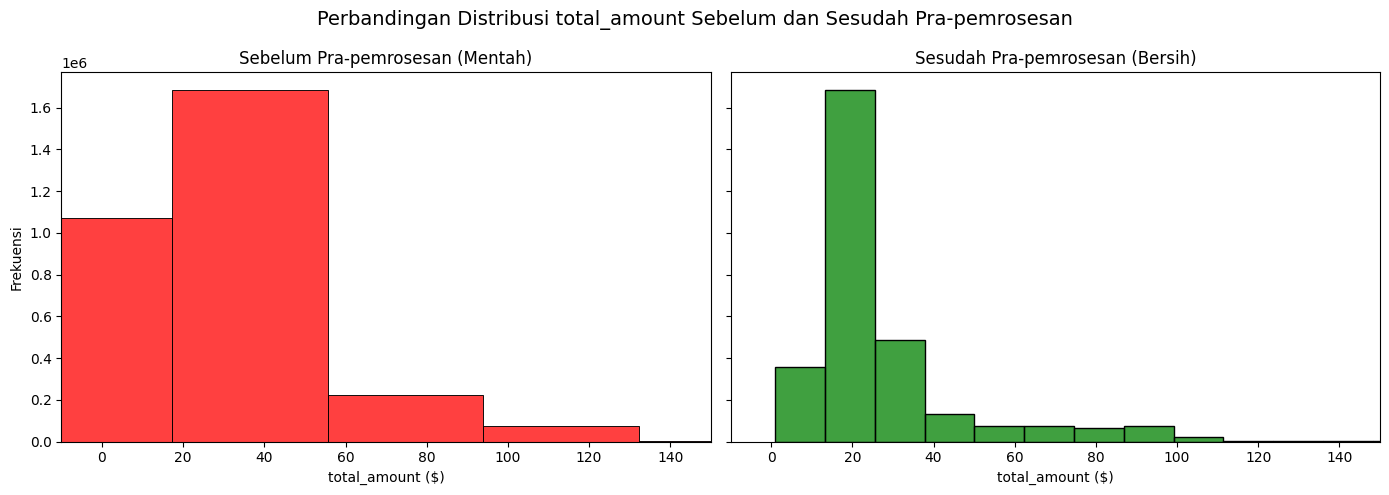

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

# sebelum Pra-pemrosesan (Data Mentah)
sns.histplot(trip["total_amount"], bins=50, ax=axes[0], color="red", kde=False)
axes[0].set_title("Sebelum Pra-pemrosesan (Mentah)")
axes[0].set_xlabel("total_amount ($)")
axes[0].set_ylabel("Frekuensi")
axes[0].set_xlim(-10, 150)

# sesudah Pra-pemrosesan (Data Bersih)
sns.histplot(hasil["total_amount"], bins=50, ax=axes[1], color="green", kde=False)
axes[1].set_title("Sesudah Pra-pemrosesan (Bersih)")
axes[1].set_xlabel("total_amount ($)")

plt.suptitle("Perbandingan Distribusi total_amount Sebelum dan Sesudah Pra-pemrosesan", fontsize=14)
plt.tight_layout()
plt.show()

STUDI KASUS

In [14]:
import pandas as pd
import os

# membentuk tabel analitik sesuai spesifikasi
tabel_analitik = (bersih
    .assign(jam_mulai=bersih["tpep_pickup_datetime"].dt.floor("h"))
    .groupby(["borough_naik", "jam_mulai"], observed=True)
    .agg(jumlah_perjalanan=("total_amount", "size"),
         rata_tarif_per_mil=("tarif_per_mil", "median"),
         rata_kecepatan=("kecepatan_mph", "median"),
         suhu_c=("suhu_c", "first"),
         hujan=("hujan", "max"))
    .reset_index())

# filter ambang minimum (minimal 30 perjalanan)
tabel_analitik = tabel_analitik[tabel_analitik["jumlah_perjalanan"] >= 30]

# tampilkan tabel perbandingan dugaan tim pricing
hasil_pricing = tabel_analitik.groupby(["borough_naik", "hujan"], observed=True)["rata_tarif_per_mil"].median().unstack()
print("Perbandingan Median Tarif per Mil (0: Tidak Hujan, 1: Hujan):")
display(hasil_pricing)

# simpan sebagai Parquet
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum3"
PATH_ANALITIK = os.path.join(DIR_SIMPAN, "tabel_analitik_pricing.parquet")
tabel_analitik.to_parquet(PATH_ANALITIK, index=False)
print(f"Tabel analitik tersimpan di: {PATH_ANALITIK}")

Perbandingan Median Tarif per Mil (0: Tidak Hujan, 1: Hujan):


hujan,0,1
borough_naik,,
Brooklyn,6.9430,7.6550
Manhattan,10.5270,11.4000
Queens,5.4530,5.6365
Unknown,8.7255,9.8860


Tabel analitik tersimpan di: /content/drive/MyDrive/BigData/Praktikum3/tabel_analitik_pricing.parquet


LATIHAN

In [15]:
import os
import time
import requests

def unduh_aman(url, path_simpan):
    nama_berkas = os.path.basename(path_simpan)

    # cek apakah berkas sudah ada (Logika Cache)
    if os.path.exists(path_simpan):
        print(f"cache ditemukan: {nama_berkas} (memakai cache, tidak mengunduh ulang)")
        return path_simpan

    # jika tidak ada di cache, mulai proses unduh
    print(f"mengunduh {nama_berkas}...")
    waktu_mulai = time.time()

    respons = requests.get(url, stream=True)
    respons.raise_for_status()

    with open(path_simpan, "wb") as f:
        for chunk in respons.iter_content(chunk_size=8192):
            f.write(chunk)

    waktu_selesai = time.time()
    durasi_detik = waktu_selesai - waktu_mulai

    # ukuran berkas dalam MB
    ukuran_bytes = os.path.getsize(path_simpan)
    ukuran_mb = ukuran_bytes / (1024 * 1024)

    # kecepatan (MB/detik)
    kecepatan = ukuran_mb / durasi_detik if durasi_detik > 0 else 0

    print(f"selesai. Kecepatan unduh: {kecepatan:.2f} MB/detik")
    return path_simpan

URL_ZONA = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
FILE_UJI = "/content/taxi_zone_uji_latihan.csv"

# hapus file uji jika sebelumnya sudah ada agar tes pertama pasti mengunduh
if os.path.exists(FILE_UJI):
    os.remove(FILE_UJI)

print("--- Panggilan Pertama (Harus Mengunduh) ---")
unduh_aman(URL_ZONA, FILE_UJI)

print("\n--- Panggilan Kedua (Harus Memakai Cache) ---")
unduh_aman(URL_ZONA, FILE_UJI)

--- Panggilan Pertama (Harus Mengunduh) ---
mengunduh taxi_zone_uji_latihan.csv...
selesai. Kecepatan unduh: 0.14 MB/detik

--- Panggilan Kedua (Harus Memakai Cache) ---
cache ditemukan: taxi_zone_uji_latihan.csv (memakai cache, tidak mengunduh ulang)


'/content/taxi_zone_uji_latihan.csv'

In [16]:
import pandas as pd

# membuat 2 aturan baru menggunakan DataFrame 'trip' yang sudah ada di memori
aturan_latihan2 = {
    "validitas: tip_amount >= 0": trip["tip_amount"] >= 0,
    "konsistensi: tip <= total_amount": trip["tip_amount"] <= trip["total_amount"]
}

# menghitung metrik kelulusan dan kegagalan
profil_latihan = []
n_total = len(trip)

for nama, kondisi in aturan_latihan2.items():
    # menangani nilai null (NA) yang akan dianggap False/Gagal jika tidak di-fill
    lulus = kondisi.fillna(False).sum()
    gagal = n_total - lulus
    profil_latihan.append({
        "aturan": nama,
        "lulus": lulus,
        "gagal": gagal,
        "persen_gagal": round((gagal / n_total) * 100, 3)
    })

# menampilkan hasil
df_latihan2 = pd.DataFrame(profil_latihan).sort_values("persen_gagal", ascending=False)
display(df_latihan2)

,aturan,lulus,gagal,persen_gagal
1,konsistensi: tip <= total_amount,3041561,25204,0.822
0,validitas: tip_amount >= 0,3066540,225,0.007


In [17]:
import pandas as pd

zona_tujuan = zona[["LocationID", "Borough"]].rename(columns={"Borough": "borough_turun"})

trip_lengkap = bersih.merge(zona_tujuan, left_on="DOLocationID", right_on="LocationID", how="left")

rute_teratas = (
    trip_lengkap.groupby(["borough_naik", "borough_turun"])
    .size()
    .reset_index(name="total_perjalanan")
    .sort_values(by="total_perjalanan", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

display(rute_teratas)

,borough_naik,borough_turun,total_perjalanan
0,Manhattan,Manhattan,2491566
1,Queens,Manhattan,155261
2,Manhattan,Queens,82354
3,Manhattan,Brooklyn,62986
4,Queens,Queens,59146
5,Queens,Brooklyn,42187
6,Unknown,Manhattan,18432
7,Unknown,Unknown,13562
8,Manhattan,Bronx,8865
9,Brooklyn,Brooklyn,7910


In [18]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# memilih fitur numerik dari data bersih Anda
kolom_fitur = ["trip_distance", "total_amount"]
data_numerik = bersih[kolom_fitur].dropna().copy()

# penskalaan dengan StandardScaler
scaler_std = StandardScaler()
df_std = pd.DataFrame(scaler_std.fit_transform(data_numerik), columns=kolom_fitur)

# penskalaan dengan MinMaxScaler
scaler_minmax = MinMaxScaler()
df_minmax = pd.DataFrame(scaler_minmax.fit_transform(data_numerik), columns=kolom_fitur)

# menampilkan perbandingan statistik
print("--- Rentang StandardScaler (Fokus pada Standardisasi) ---")
display(df_std.agg(["min", "max", "mean", "std"]).round(4))

print("\n--- Rentang MinMaxScaler (Fokus pada Normalisasi 0-1) ---")
display(df_minmax.agg(["min", "max", "mean", "std"]).round(4))

--- Rentang StandardScaler (Fokus pada Standardisasi) ---


,trip_distance,total_amount
min,-0.7769,-1.2447
max,21.2170,27.7594
mean,0.0000,-0.0000
std,1.0000,1.0000



--- Rentang MinMaxScaler (Fokus pada Normalisasi 0-1) ---


,trip_distance,total_amount
min,0.0000,0.0000
max,1.0000,1.0000
mean,0.0353,0.0429
std,0.0455,0.0345


In [19]:
import pandas as pd

print("--- 1. Kondisi Awal ---")
print(f"Jumlah baris tabel zona asli: {len(zona)}")

print("\n--- 2. Menggandakan Satu Baris ---")
# mengambil baris pertama dan menambahkannya ke akhir tabel zona
baris_tambahan = zona.iloc[[0]]
zona = pd.concat([zona, baris_tambahan], ignore_index=True)
print(f"Jumlah baris tabel zona setelah digandakan: {len(zona)}")

print("\n--- 3. Menguji validate='many_to_one' ---")
try:
    trip_gagal = bersih.merge(
        zona,
        left_on="PULocationID",
        right_on="LocationID",
        how="left",
        validate="many_to_one"
    )
except Exception as e:
    print("ERROR BERHASIL DITANGKAP!")
    print(f"Tipe Error: {type(e).__name__}")
    print(f"Pesan Error: {e}")

print("\n--- 4. Mengembalikan Tabel ke Keadaan Semula ---")
zona = zona.drop_duplicates(subset=["LocationID"], keep="first").reset_index(drop=True)
print(f"Jumlah baris tabel zona setelah dipulihkan: {len(zona)}")
print("Status: Tabel zona telah kembali normal.")

--- 1. Kondisi Awal ---
Jumlah baris tabel zona asli: 265

--- 2. Menggandakan Satu Baris ---
Jumlah baris tabel zona setelah digandakan: 266

--- 3. Menguji validate='many_to_one' ---
ERROR BERHASIL DITANGKAP!
Tipe Error: MergeError
Pesan Error: Merge keys are not unique in right dataset; not a many-to-one merge

--- 4. Mengembalikan Tabel ke Keadaan Semula ---
Jumlah baris tabel zona setelah dipulihkan: 265
Status: Tabel zona telah kembali normal.


In [20]:
import os
import pandas as pd

def pipeline_inkremental(bulan):
    DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum3"
    # memastikan direktori utama ada
    os.makedirs(DIR_SIMPAN, exist_ok=True)

    # format penamaan berkas keluaran yang seragam berdasarkan bulan
    nama_file = f"tripdata_bersih_{bulan}.parquet"
    path_output = os.path.join(DIR_SIMPAN, nama_file)

    if os.path.exists(path_output):
        print(f"[IDEMPOTEN] Data bulan '{bulan}' sudah ada di direktori keluaran.")
        print(f"-> Eksekusi dihentikan/dilewati. Tidak ada berkas baru yang dibuat.")
        return path_output

    print(f"[PROSES BARU] Data bulan '{bulan}' belum ada.")
    print(f"-> Memulai unduhan dan pipeline pra-pemrosesan untuk {bulan}...")

    # simulasi penyimpanan hasil akhir sebagai Parquet
    df_simulasi = pd.DataFrame({"bulan": [bulan], "status": ["sukses"]})
    df_simulasi.to_parquet(path_output, index=False)

    print(f"-> Selesai! Berkas baru tersimpan di: {path_output}")
    return path_output


BULAN_UJI = "2023-11"

print("--- Panggilan Pertama (Harus Memproses) ---")
path_hasil_1 = pipeline_inkremental(BULAN_UJI)

print("\n--- Panggilan Kedua (Harus Melewati) ---")
path_hasil_2 = pipeline_inkremental(BULAN_UJI)

--- Panggilan Pertama (Harus Memproses) ---
[PROSES BARU] Data bulan '2023-11' belum ada.
-> Memulai unduhan dan pipeline pra-pemrosesan untuk 2023-11...
-> Selesai! Berkas baru tersimpan di: /content/drive/MyDrive/BigData/Praktikum3/tripdata_bersih_2023-11.parquet

--- Panggilan Kedua (Harus Melewati) ---
[IDEMPOTEN] Data bulan '2023-11' sudah ada di direktori keluaran.
-> Eksekusi dihentikan/dilewati. Tidak ada berkas baru yang dibuat.


TUGAS

In [21]:
import pandas as pd
import os

DIR_PARTISI = "/content/drive/MyDrive/BigData/Praktikum3/Dataset_Partisi_Tugas1"

bulan_uji = ["2023-01", "2023-07"]

for bulan in bulan_uji:
    print(f"=== Menjalankan Pipeline untuk {bulan} ===")

    # unduh Data Mentah (memanfaatkan fungsi Latihan 1)
    url = f"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_{bulan}.parquet"
    file_lokal = f"/content/yellow_tripdata_{bulan}.parquet"
    unduh_aman(url, file_lokal)

    # baca Data ke Pandas
    df = pd.read_parquet(file_lokal)

    # pra-pemrosesan (Simulasi standar K-4 s.d. K-6)
    kolom_penting = ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'trip_distance', 'total_amount']
    df_bersih = df[kolom_penting].dropna().copy()

    # buat Kolom Partisi
    df_bersih['bulan_eksekusi'] = bulan

    # simpan Data ke Direktori Berpartisi
    print(f"Menyimpan ke direktori partisi...")
    df_bersih.to_parquet(
        DIR_PARTISI,
        partition_cols=['bulan_eksekusi'],
        engine='pyarrow',
        index=False
    )
    print(f"Selesai untuk {bulan}!\n")

print("=== Pembuktian Hasil Partisi ===")
df_hasil = pd.read_parquet(DIR_PARTISI)

bukti_partisi = df_hasil.groupby('bulan_eksekusi').size().reset_index(name='total_baris_bersih')
display(bukti_partisi)

=== Menjalankan Pipeline untuk 2023-01 ===
mengunduh yellow_tripdata_2023-01.parquet...
selesai. Kecepatan unduh: 76.88 MB/detik
Menyimpan ke direktori partisi...
Selesai untuk 2023-01!

=== Menjalankan Pipeline untuk 2023-07 ===
mengunduh yellow_tripdata_2023-07.parquet...
selesai. Kecepatan unduh: 53.49 MB/detik
Menyimpan ke direktori partisi...
Selesai untuk 2023-07!

=== Pembuktian Hasil Partisi ===


/tmp/ipykernel_1870/1454025384.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bukti_partisi = df_hasil.groupby('bulan_eksekusi').size().reset_index(name='total_baris_bersih')


,bulan_eksekusi,total_baris_bersih
0,2023-01,3066766
1,2023-07,2907108


In [22]:
import pandas as pd

def buat_laporan_kualitas(file_path):
    # membaca data mentah
    df = pd.read_parquet(file_path)

    # kumpulan aturan validitas & konsistensi (K-6 + Latihan 2)
    aturan = {
        "penumpang > 0": df["passenger_count"] > 0,
        "jarak > 0": df["trip_distance"] > 0,
        "tarif >= 0": df["fare_amount"] >= 0,
        "tip >= 0": df["tip_amount"] >= 0,
        "tip <= total": df["tip_amount"] <= df["total_amount"]
    }

    n_total = len(df)
    profil = []

    for nama, kondisi in aturan.items():
        # menghitung yang gagal (termasuk nilai NaN)
        gagal = n_total - kondisi.fillna(False).sum()
        persen_gagal = (gagal / n_total) * 100
        profil.append({
            "aturan": nama,
            "persen_gagal": persen_gagal
        })

    return pd.DataFrame(profil)

print("Memproses data Januari 2023...")
df_jan = buat_laporan_kualitas("/content/yellow_tripdata_2023-01.parquet").rename(columns={"persen_gagal": "gagal_Jan(%)"})

print("Memproses data Juli 2023...")
df_jul = buat_laporan_kualitas("/content/yellow_tripdata_2023-07.parquet").rename(columns={"persen_gagal": "gagal_Jul(%)"})

# menggabungkan kedua laporan dan menghitung selisih absolutnya
df_komparasi = df_jan.merge(df_jul, on="aturan")
df_komparasi["selisih_absolut(%)"] = abs(df_komparasi["gagal_Jan(%)"] - df_komparasi["gagal_Jul(%)"])

# menampilkan tabel komparatif yang diurutkan dari selisih terbesar
print("\n=== Tabel Komparatif Laporan Kualitas ===")
display(df_komparasi.round(3).sort_values("selisih_absolut(%)", ascending=False).reset_index(drop=True))

Memproses data Januari 2023...
Memproses data Juli 2023...

=== Tabel Komparatif Laporan Kualitas ===


,aturan,gagal_Jan(%),gagal_Jul(%),selisih_absolut(%)
0,penumpang > 0,4.008,4.431,0.423
1,tarif >= 0,0.817,1.072,0.255
2,tip <= total,0.822,1.060,0.238
3,jarak > 0,1.495,1.713,0.217
4,tip >= 0,0.007,0.004,0.003


In [23]:
import pandas as pd
import requests

print("=== 1. Proses Akuisisi Data API (Hari Libur Nasional AS 2023) ===")
url_api = "https://date.nager.at/api/v3/PublicHolidays/2023/US"
respons = requests.get(url_api)

if respons.status_code == 200:
    df_libur = pd.DataFrame(respons.json())

    df_libur = df_libur[['date', 'name']].rename(columns={'date': 'tanggal_libur', 'name': 'nama_libur'})
    df_libur['tanggal_libur'] = pd.to_datetime(df_libur['tanggal_libur']).dt.date

    print("Data hari libur berhasil diakuisisi:")
    display(df_libur.head())
else:
    print("Gagal mengambil data dari API.")

print("\n=== 2. Proses Integrasi dengan Data Taksi ===")
df_taksi = pd.read_parquet(
    "/content/yellow_tripdata_2023-01.parquet",
    columns=['tpep_pickup_datetime', 'trip_distance', 'total_amount']
)

df_taksi['tanggal_pickup'] = pd.to_datetime(df_taksi['tpep_pickup_datetime']).dt.date

df_terintegrasi = df_taksi.merge(
    df_libur,
    left_on='tanggal_pickup',
    right_on='tanggal_libur',
    how='left'
)

df_terintegrasi['nama_libur'] = df_terintegrasi['nama_libur'].fillna('Bukan Libur')

print("Distribusi Perjalanan Berdasarkan Hari Libur (Januari 2023):")
display(df_terintegrasi['nama_libur'].value_counts().head())

=== 1. Proses Akuisisi Data API (Hari Libur Nasional AS 2023) ===
Data hari libur berhasil diakuisisi:


,tanggal_libur,nama_libur
0,2023-01-02,New Year's Day
1,2023-01-16,"Martin Luther King, Jr. Day"
2,2023-02-12,Lincoln's Birthday
3,2023-02-20,Presidents Day
4,2023-04-07,Good Friday



=== 2. Proses Integrasi dengan Data Taksi ===
Distribusi Perjalanan Berdasarkan Hari Libur (Januari 2023):


,count
nama_libur,
Bukan Libur,2920869
"Martin Luther King, Jr. Day",80120
New Year's Day,65777


In [24]:
isi_kamus_data = """# Kamus Data (Data Dictionary) - NYC Yellow Taxi Trip Data

Kamus data ini mendokumentasikan skema dataset akhir hasil pra-pemrosesan dan penggabungan multi-sumber (TLC Trip Record, Zone Lookup, dan Nager.Date API).

| Nama Kolom | Tipe Data | Satuan | Sumber | Aturan Validitas | Penanganan Nilai Hilang |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **tpep_pickup_datetime** | `datetime64[ns]` | Waktu (YYYY-MM-DD) | TLC Trip Record | Harus lebih kecil dari waktu dropoff | Baris dibuang (dropna) |
| **tpep_dropoff_datetime** | `datetime64[ns]` | Waktu (YYYY-MM-DD) | TLC Trip Record | Harus lebih besar dari waktu pickup | Baris dibuang (dropna) |
| **passenger_count** | `float64` | Orang | TLC Trip Record | passenger_count > 0 | Baris dibuang (filtering) |
| **trip_distance** | `float64` | Mil (Miles) | TLC Trip Record | trip_distance > 0 | Baris dibuang (filtering) |
| **PULocationID** | `int64` | ID Numerik | TLC Trip Record | Nilai 1 s.d. 265 | Baris dibuang jika lookup gagal |
| **DOLocationID** | `int64` | ID Numerik | TLC Trip Record | Nilai 1 s.d. 265 | Baris dibuang jika lookup gagal |
| **Borough** | `string` | Teks | TLC Zone Lookup | Tidak boleh bernilai 'Unknown' | Baris dibuang (filtering) |
| **Zone** | `string` | Teks | TLC Zone Lookup | Sesuai daftar zona Kota New York | Diabaikan / Dibiarkan |
| **fare_amount** | `float64` | USD | TLC Trip Record | fare_amount >= 0 | Dikonversi ke absolut / dibuang |
| **tip_amount** | `float64` | USD | TLC Trip Record | tip_amount >= 0 & <= total_amount | Dibatasi (capping) / dibuang |
| **total_amount** | `float64` | USD | TLC Trip Record | total_amount > 0 | Baris dibuang (filtering) |
| **tanggal_pickup** | `object (date)` | Tanggal (YYYY-MM-DD) | Ekstraksi Internal | Valid pada kalender 2023 | Terisi otomatis dari ekstraksi |
| **nama_libur** | `string` | Teks | Nager.Date API | Sesuai nama hari libur nasional AS | Diimputasi dengan 'Bukan Libur' |
"""

with open("kamus_data.md", "w") as f:
    f.write(isi_kamus_data)

print("--- Berkas 'kamus_data.md' berhasil dibuat! ---")
print("\nVerifikasi Tipe Data pada DataFrame Akhir (df_terintegrasi):")
display(df_terintegrasi.dtypes)

--- Berkas 'kamus_data.md' berhasil dibuat! ---

Verifikasi Tipe Data pada DataFrame Akhir (df_terintegrasi):


,0
tpep_pickup_datetime,datetime64[us]
trip_distance,float64
total_amount,float64
tanggal_pickup,object
tanggal_libur,object
nama_libur,object
